## Import & Setup

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE

from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import FunctionTransformer

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
import numpy as np
from sklearn.metrics import f1_score

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report, roc_auc_score


In [2]:
df_original = pd.read_csv('../data/dataset.csv')
df_original.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


## Basic data exploration

In [3]:
df_original.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 140.4 KB


In [4]:
df_original.describe()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


In [5]:
df_original.columns

Index(['age', 'gender', 'daily_social_media_hours', 'platform_usage',
       'sleep_hours', 'screen_time_before_sleep', 'academic_performance',
       'physical_activity', 'social_interaction_level', 'stress_level',
       'anxiety_level', 'addiction_level', 'depression_label'],
      dtype='str')

## Data Cleaning

In [6]:
df = df_original.copy()

### Missing Data Check

In [7]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

- No missing data found.

### Duplication check

In [8]:
df.duplicated().sum()

np.int64(0)

- No duplicate data found.

## EDA

### Target Distribution

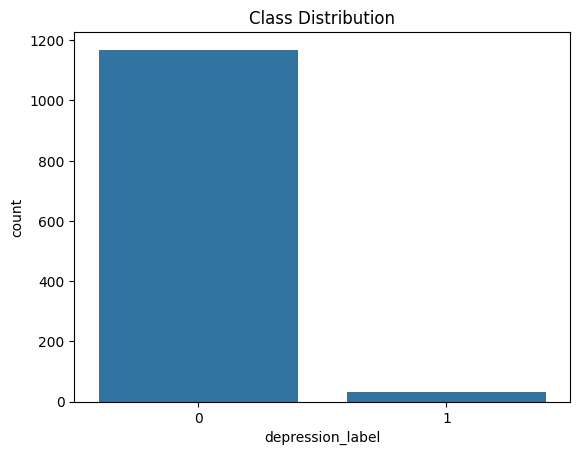

In [9]:
sns.countplot(x = 'depression_label', data = df)
plt.title('Class Distribution')
plt.show()

### Numeric Distribution

In [10]:
num_cols = df.select_dtypes(include=['int', 'float']).columns

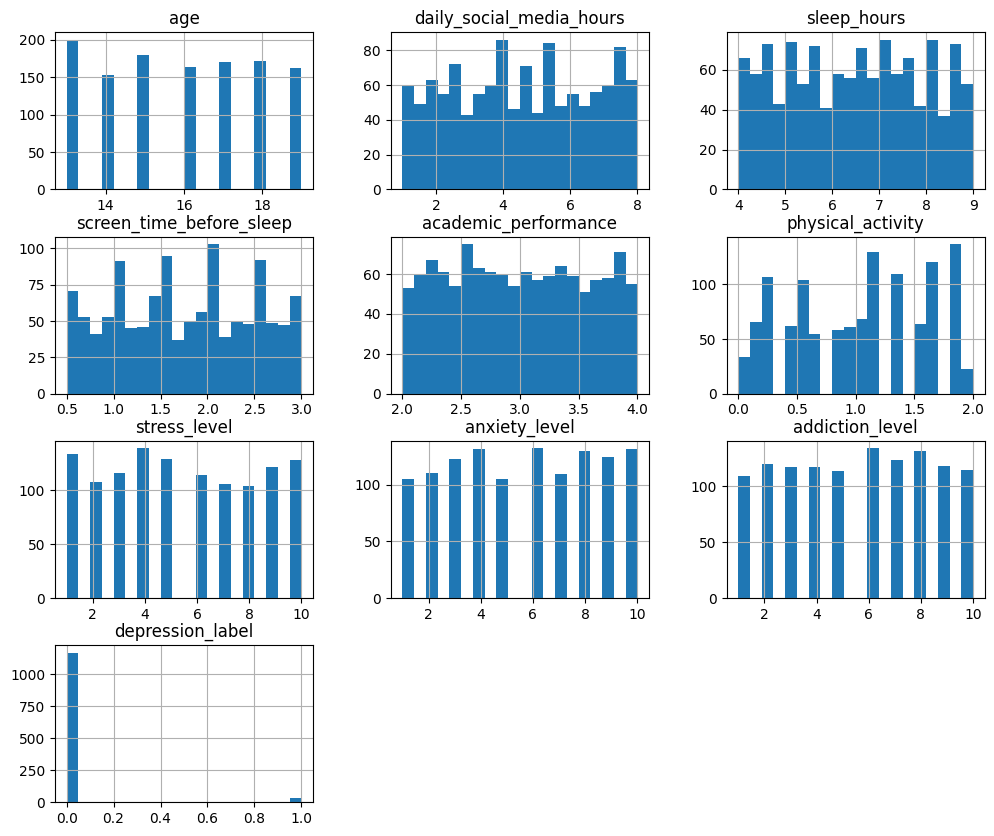

In [11]:
df[num_cols].hist(figsize=(12,10), bins=20)
plt.show()

### Correlation Heatmap

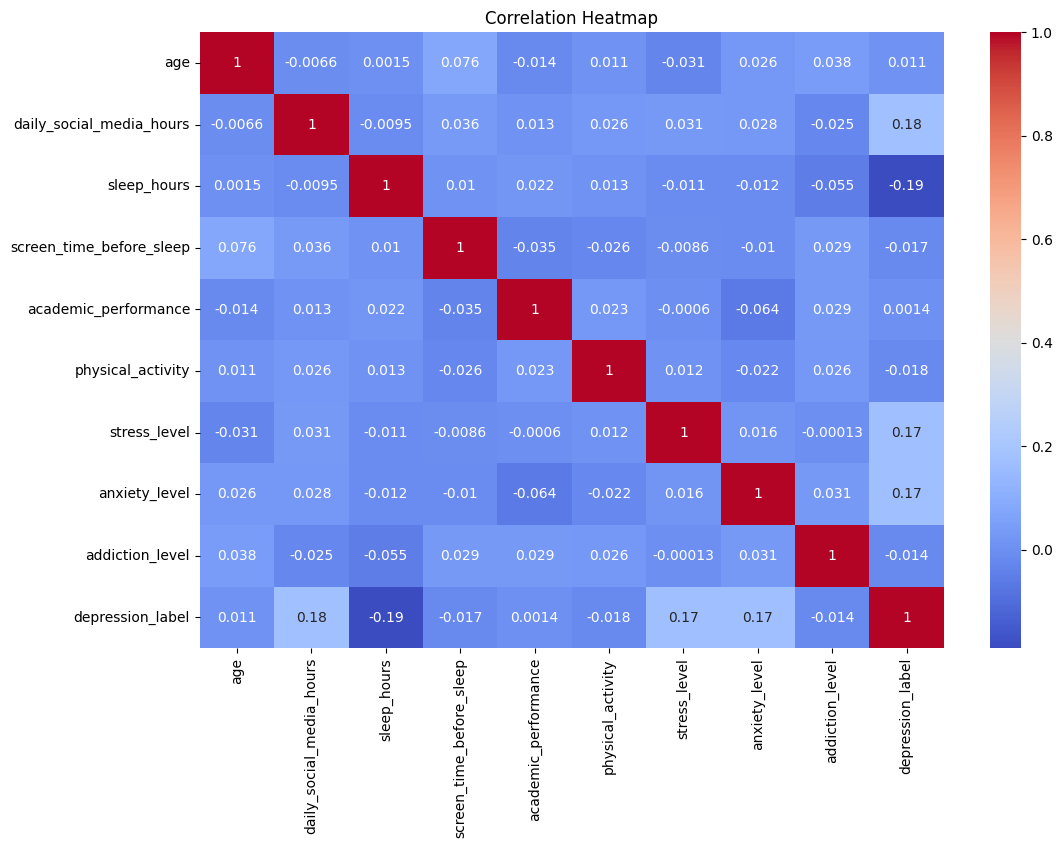

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

### Critical Analysis of Psychological Features

In [13]:
df.groupby("depression_label")[["stress_level", "anxiety_level", "addiction_level"]].mean()

,stress_level,anxiety_level,addiction_level
depression_label,,,
0,5.365269,5.557742,5.571429
1,8.483871,8.612903,5.322581


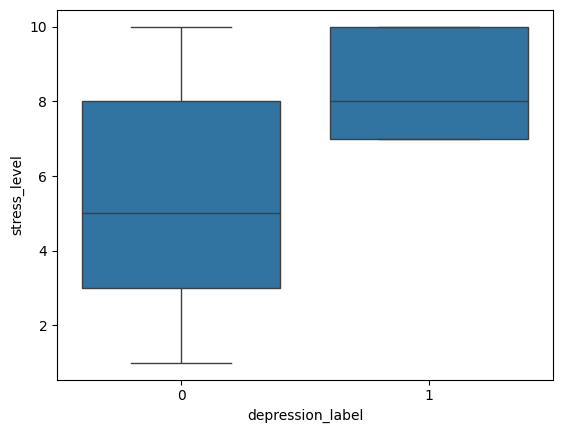

In [14]:
sns.boxplot(x="depression_label", y="stress_level", data=df)
plt.show()

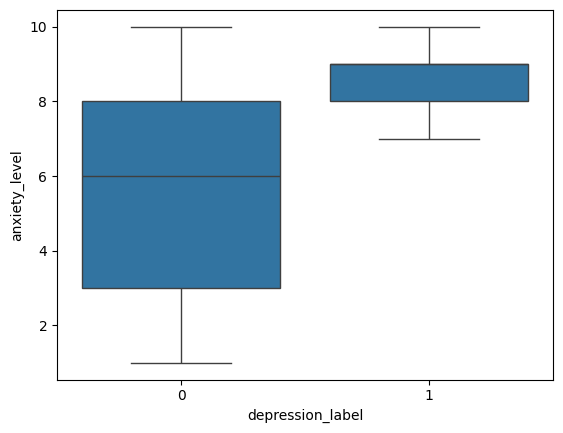

In [15]:
sns.boxplot(x="depression_label", y="anxiety_level", data=df)
plt.show()

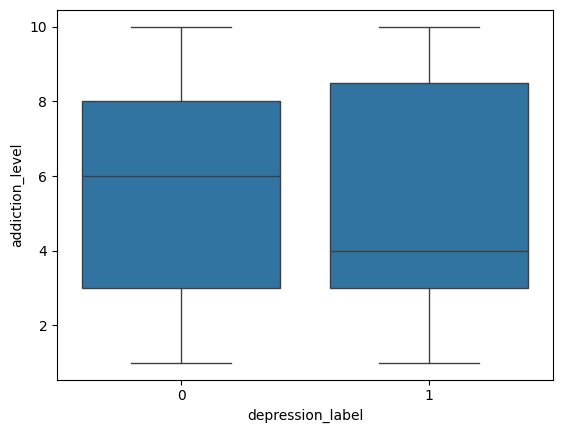

In [16]:
sns.boxplot(x="depression_label", y="addiction_level", data=df)
plt.show()

### Behavioral Features vs Target

#### Sleep

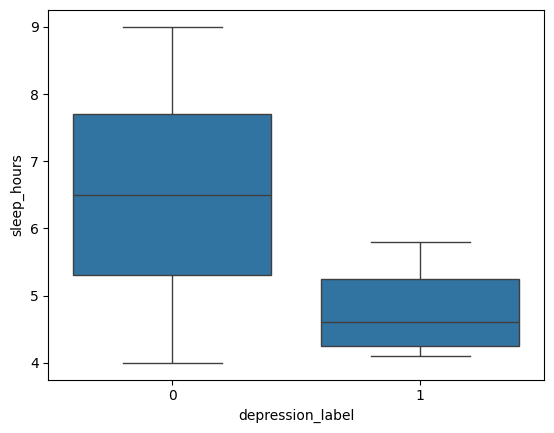

In [17]:
sns.boxplot(x="depression_label", y="sleep_hours", data=df)
plt.show()

#### Social Media Usage

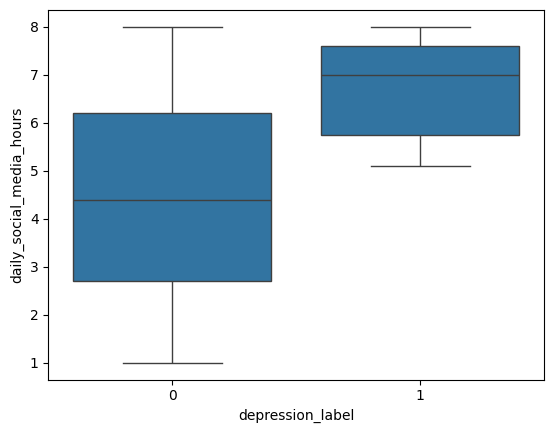

In [18]:
sns.boxplot(x="depression_label", y="daily_social_media_hours", data=df)
plt.show()

#### Physical Activity

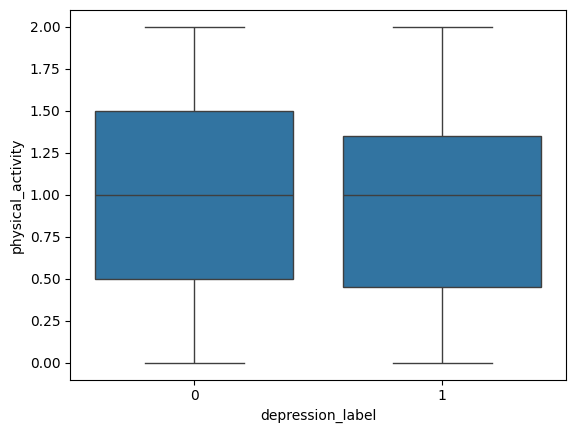

In [19]:
sns.boxplot(x="depression_label", y="physical_activity", data=df)
plt.show()

#### Screentime before sleep

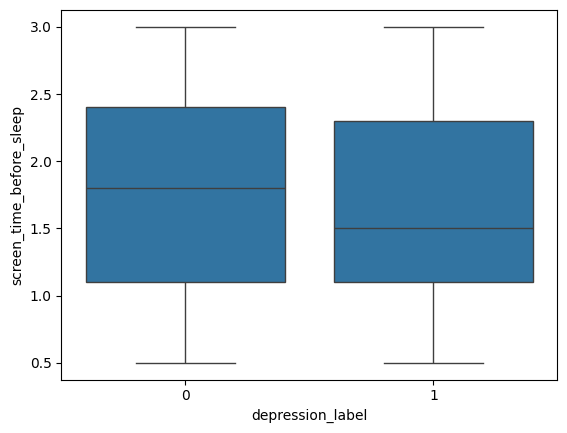

In [20]:
sns.boxplot(x="depression_label", y="screen_time_before_sleep", data=df)
plt.show()

### Categorical Features

#### Gender

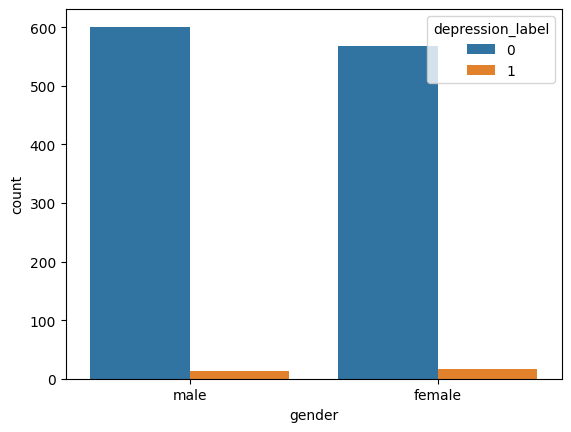

In [21]:
sns.countplot(x="gender", hue="depression_label", data=df)
plt.show()

#### Platform Usage

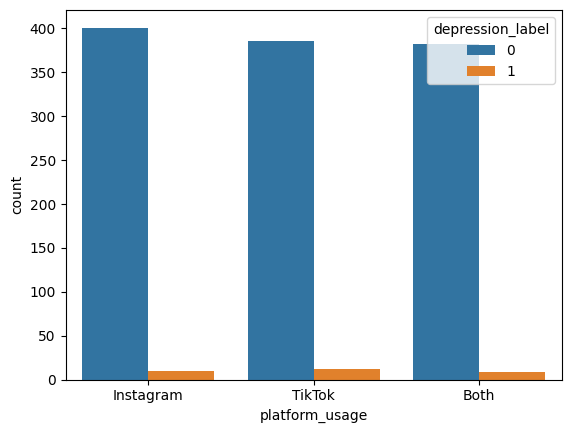

In [22]:
sns.countplot(x="platform_usage", hue="depression_label", data=df)
plt.show()

#### Social Interaction

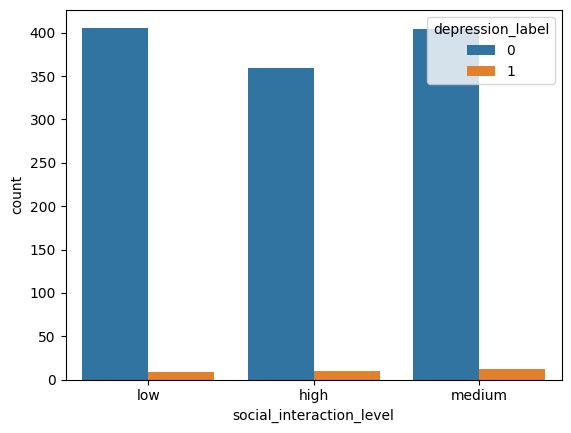

In [23]:
sns.countplot(x="social_interaction_level", hue="depression_label", data=df)
plt.show()

# Feature Extraction

## Feature Transformation

### Ordinal Encoding of **social_interaction_level** column

In [24]:
df['social_interaction_level'].unique()

<ArrowStringArray>
['low', 'high', 'medium']
Length: 3, dtype: str

In [25]:
interaction_encoder = OrdinalEncoder(categories=[["low", "medium", "high"]])

df["social_interaction_level"] = interaction_encoder.fit_transform(
    df[["social_interaction_level"]]
)

### Label Encoding of **gender** column

In [26]:
gender_encoder = OrdinalEncoder()

df["gender"] = gender_encoder.fit_transform(df[["gender"]])

### One-hot encoding

In [27]:
platform_encoder = OneHotEncoder(drop="first", sparse_output=False)

platform_encoded = platform_encoder.fit_transform(df[["platform_usage"]])

platform_cols = platform_encoder.get_feature_names_out(["platform_usage"])

platform_df = pd.DataFrame(platform_encoded, columns=platform_cols, index=df.index)

# Drop original column and merge encoded columns
df = df.drop(columns=["platform_usage"])
df = pd.concat([df, platform_df], axis=1)

In [28]:
df.head()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Instagram,platform_usage_TikTok
0,14,1.0,7.9,7.4,2.9,3.01,1.5,0.0,2,2,1,0,1.0,0.0
1,19,0.0,1.9,8.0,2.9,3.22,0.8,2.0,8,1,10,0,0.0,1.0
2,17,0.0,1.3,7.6,0.5,3.92,0.0,2.0,2,4,2,0,1.0,0.0
3,15,1.0,7.4,6.9,1.6,3.48,0.8,1.0,1,7,9,0,0.0,1.0
4,15,0.0,4.7,4.9,3.0,2.37,1.4,1.0,3,5,2,0,0.0,0.0


## Feature Construction

### Screen vs Sleep Ratio

In [29]:
df['screen_sleep_ratio'] = df['screen_time_before_sleep'] / df['sleep_hours']

### Social vs Physical Balance

In [30]:
df['social_physical_ratio'] = df['daily_social_media_hours'] / (df['physical_activity'] + 0.1)

### High Usage Flag

In [31]:
df["high_social_usage"] = (df["daily_social_media_hours"] > 6).astype(int)

### Low Sleep Flag

In [32]:
df["low_sleep"] = (df["sleep_hours"] < 6).astype(int)

### Combined Psychological Score

In [33]:
df["mental_health_score"] = (
    df["stress_level"] + df["anxiety_level"] + df["addiction_level"]
) / 3

In [34]:
df.head()

,age,gender,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label,platform_usage_Instagram,platform_usage_TikTok,screen_sleep_ratio,social_physical_ratio,high_social_usage,low_sleep,mental_health_score
0,14,1.0,7.9,7.4,2.9,3.01,1.5,0.0,2,2,1,0,1.0,0.0,0.391892,4.937500,1,0,1.666667
1,19,0.0,1.9,8.0,2.9,3.22,0.8,2.0,8,1,10,0,0.0,1.0,0.362500,2.111111,0,0,6.333333
2,17,0.0,1.3,7.6,0.5,3.92,0.0,2.0,2,4,2,0,1.0,0.0,0.065789,13.000000,0,0,2.666667
3,15,1.0,7.4,6.9,1.6,3.48,0.8,1.0,1,7,9,0,0.0,1.0,0.231884,8.222222,1,0,5.666667
4,15,0.0,4.7,4.9,3.0,2.37,1.4,1.0,3,5,2,0,0.0,0.0,0.612245,3.133333,0,1,3.333333


## Separate features

In [35]:
X = df.drop("depression_label", axis=1)
y = df["depression_label"]

## Correlation

In [36]:
corr = df.corr()["depression_label"].abs().sort_values(ascending=False)
corr

depression_label            1.000000
low_sleep                   0.199443
sleep_hours                 0.190630
mental_health_score         0.186638
daily_social_media_hours    0.175201
stress_level                0.170474
anxiety_level               0.169566
high_social_usage           0.155837
screen_sleep_ratio          0.088927
social_physical_ratio       0.077009
gender                      0.019836
platform_usage_TikTok       0.019172
physical_activity           0.017598
screen_time_before_sleep    0.016502
social_interaction_level    0.014238
addiction_level             0.013952
age                         0.010973
platform_usage_Instagram    0.006836
academic_performance        0.001441
Name: depression_label, dtype: float64

## Train test split

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Keep imbalance consistent in both dataset
)

## scale_pos_weight for XGBoost model

In [38]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

In [39]:
scale_pos_weight = neg / pos

## Scaling for Logistic Regression

In [40]:
scaler = StandardScaler()

In [41]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Model Selection

## Baseline Models

In [42]:
models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", max_iter=1000),
    "Random Forest": RandomForestClassifier(class_weight="balanced", random_state=42),
    "XGBoost": XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric='logloss'
    ),
    "Decision Tree": DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42
)
}

## SMOTE for Imbalance handling

In [43]:
smote = SMOTE(random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

In [44]:
X_train_sm_scaled = scaler.fit_transform(X_train_sm)

## Model with SMOTE

In [45]:
models_smote = {
    "Logistic Regression + SMOTE": LogisticRegression(max_iter=1000),
    "Random Forest + SMOTE": RandomForestClassifier(random_state=42),
    "XGBoost + SMOTE": XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    "Decision Tree + SMOTE": DecisionTreeClassifier(
    random_state=42
)
}

## Training & Evaluation

In [46]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(4,3))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=["No Depression", "Depression"],
        yticklabels=["No Depression", "Depression"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

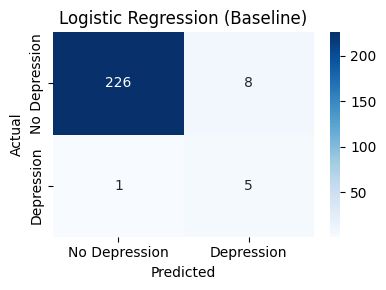

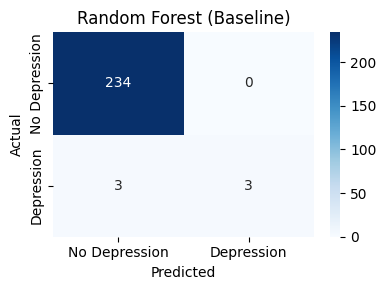

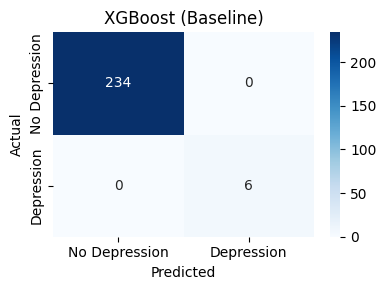

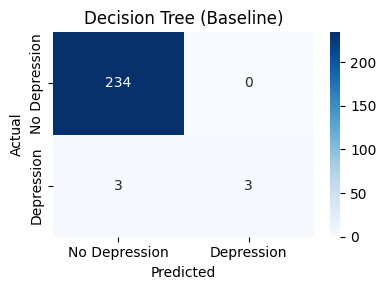

In [47]:
results = []

for name, model in models.items():
    
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]
    
    plot_conf_matrix(y_test, preds, f"{name} (Baseline)")
    report = classification_report(y_test, preds, output_dict=True)
    roc = roc_auc_score(y_test, probs)
    
    results.append({
        "Model": name,
        "accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "ROC-AUC": roc
    })

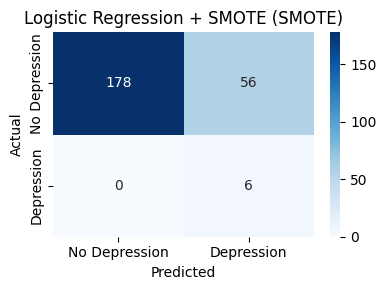

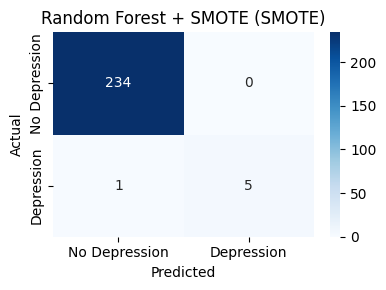

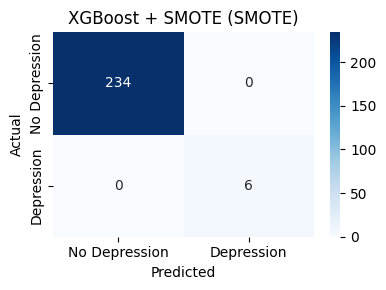

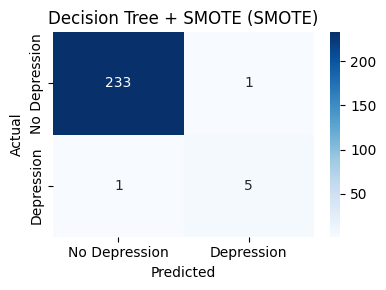

In [48]:
for name, model in models_smote.items():
    
    if "Logistic" in name:
        model.fit(X_train_sm_scaled, y_train_sm)
        preds = model.predict(X_test_scaled)
        probs = model.predict_proba(X_test_scaled)[:,1]
    else:
        model.fit(X_train_sm, y_train_sm)
        preds = model.predict(X_test)
        probs = model.predict_proba(X_test)[:,1]
    
    report = classification_report(y_test, preds, output_dict=True)
    roc = roc_auc_score(y_test, probs)
    plot_conf_matrix(y_test, preds, f"{name} (SMOTE)")
    
    results.append({
        "Model": name,
        "accuracy": report["accuracy"],
        "Precision": report["1"]["precision"],
        "Recall": report["1"]["recall"],
        "F1-Score": report["1"]["f1-score"],
        "ROC-AUC": roc
    })


In [49]:
df_results = pd.DataFrame(results).sort_values(by="F1-Score", ascending=False)
df_results

,Model,accuracy,Precision,Recall,F1-Score,ROC-AUC
2,XGBoost,1.000000,1.000000,1.000000,1.000000,1.000000
6,XGBoost + SMOTE,1.000000,1.000000,1.000000,1.000000,1.000000
5,Random Forest + SMOTE,0.995833,1.000000,0.833333,0.909091,1.000000
7,Decision Tree + SMOTE,0.991667,0.833333,0.833333,0.833333,0.914530
1,Random Forest,0.987500,1.000000,0.500000,0.666667,1.000000
3,Decision Tree,0.987500,1.000000,0.500000,0.666667,0.750000
0,Logistic Regression,0.962500,0.384615,0.833333,0.526316,0.989316
4,Logistic Regression + SMOTE,0.766667,0.096774,1.000000,0.176471,0.989316


# Hyper-parameter tuning of **Logistic Regression + SMOTE** model

In [50]:
param_grid = {
    "C": [0.01, 0.1, 1, 10],
    "solver": ["lbfgs"]
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring="precision",
    cv=3,
    n_jobs=-1
)

grid_lr.fit(X_train_sm_scaled, y_train_sm)

best_lr = grid_lr.best_estimator_
print("Best Params:", grid_lr.best_params_)

Best Params: {'C': 10, 'solver': 'lbfgs'}


In [51]:
probs = best_lr.predict_proba(X_test_scaled)[:,1]

thresholds = np.arange(0.3, 0.9, 0.05)

best_threshold = 0.5
best_f1 = 0

for t in thresholds:
    preds = (probs > t).astype(int)
    
    f1 = f1_score(y_test, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = t

print("Best Threshold:", best_threshold)

Best Threshold: 0.8999999999999999


In [52]:
final_preds = (probs > best_threshold).astype(int)

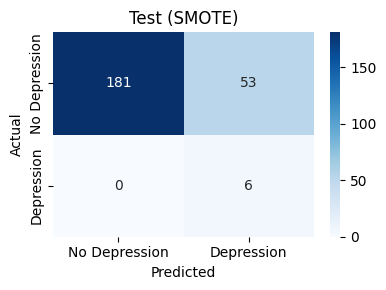

In [53]:
y_best = best_lr.predict(X_test_scaled)
plot_conf_matrix(y_true=y_test, y_pred=y_best, title="Test (SMOTE)")

In [54]:
print(classification_report(y_true=y_test, y_pred=y_best))

              precision    recall  f1-score   support

           0       1.00      0.77      0.87       234
           1       0.10      1.00      0.18         6

    accuracy                           0.78       240
   macro avg       0.55      0.89      0.53       240
weighted avg       0.98      0.78      0.86       240



# Save for deployment

## Save Encoders

In [55]:
import joblib

encoders = {
    "interaction_encoder": interaction_encoder,
    "gender_encoder": gender_encoder,
    "platform_encoder": platform_encoder
}

joblib.dump(encoders, "../models/encoders.pkl")

['../models/encoders.pkl']

## Save Best Model

In [56]:
joblib.dump(best_lr, "../models/model.pkl")

['../models/model.pkl']

## Build FINAL Pipeline

In [57]:
def add_features(X):
    X = X.copy()

    X["screen_sleep_ratio"] = X["screen_time_before_sleep"] / X["sleep_hours"]
    X["social_physical_ratio"] = X["daily_social_media_hours"] / (X["physical_activity"] + 0.1)

    X["high_social_usage"] = (X["daily_social_media_hours"] > 6).astype(int)
    X["low_sleep"] = (X["sleep_hours"] < 6).astype(int)

    X["mental_health_score"] = (
        X["stress_level"] +
        X["anxiety_level"] +
        X["addiction_level"]
    ) / 3

    return X

feature_engineering = FunctionTransformer(add_features)

In [58]:
categorical_cols = ["platform_usage"]
ordinal_cols = ["social_interaction_level"]
binary_cols = ["gender"]

numerical_cols = [
    "age",
    "daily_social_media_hours",
    "sleep_hours",
    "screen_time_before_sleep",
    "academic_performance",
    "physical_activity",
    "stress_level",
    "anxiety_level",
    "addiction_level",

    # ENGINEERED FEATURES
    "screen_sleep_ratio",
    "social_physical_ratio",
    "high_social_usage",
    "low_sleep",
    "mental_health_score"
]

preprocessor = ColumnTransformer([
    ("platform", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
    ("interaction", OrdinalEncoder(categories=[["low", "medium", "high"]]), ordinal_cols),
    ("gender", OrdinalEncoder(), binary_cols),
    ("num", "passthrough", numerical_cols)
])

In [59]:
pipeline = Pipeline([
    ("feature_engineering", feature_engineering),
    ("preprocessing", preprocessor),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

In [60]:
X = df_original.drop("depression_label", axis=1)
y = df_original['depression_label']

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Keep imbalance consistent in both dataset
)

In [62]:
pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessing', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function add...x774802896d40>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",None
,"kw_args kw_args: dict, default=NoneDictionary of additional keywor

In [63]:
joblib.dump(pipeline, "../models/pipeline.pkl")

['../models/pipeline.pkl']